# PPO on φ·ψ — point_Spiral11x11 Results

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

## Config

In [2]:
LOG_DIR = '/home/gliu2/dist_matching/sgcrl/logs/ppo_spiral11x11/'
ENV     = 'point_Spiral11x11'
ALG     = 'ppo'
SEEDS   = [0, 1, 2]

## Helper functions

In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w


def load_eval_csv(log_dir, alg, env, seed):
    path = os.path.join(log_dir, f'{alg}_{env}_{seed}', 'logs', 'eval', 'logs.csv')
    return pd.read_csv(path)


def load_learner_csv(log_dir, alg, env, seed):
    path = os.path.join(log_dir, f'{alg}_{env}_{seed}', 'logs', 'learner', 'logs.csv')
    return pd.read_csv(path)


def resample(series, n=500):
    idx = np.round(np.linspace(0, len(series) - 1, n)).astype(int)
    return series.iloc[idx]


def plot_metric(log_dir, alg, env, seeds, metric='success_1000',
                x_col='learner_steps', csv_loader=load_eval_csv,
                label=None, color='steelblue', num_sample=500,
                smoothing=None, **kwargs):
    arrays = []
    xs = None
    for seed in seeds:
        try:
            df = csv_loader(log_dir, alg, env, seed)
        except FileNotFoundError:
            print(f'  [warn] missing seed {seed}')
            continue
        x = resample(df[x_col], num_sample).values
        y = resample(df[metric], num_sample).values
        if xs is None:
            xs = x
        arrays.append(y)

    if not arrays:
        print(f'No data found for {alg}/{env}/{metric}')
        return

    arr  = np.array(arrays)
    mean = np.mean(arr, axis=0)
    sem  = stats.sem(arr, axis=0)

    if smoothing:
        mean = moving_average(mean, smoothing)
        sem  = moving_average(sem,  smoothing)
        xs   = xs[smoothing - 1:]

    lbl = label or f'{alg} ({len(arrays)} seeds)'
    plt.plot(xs, mean, label=lbl, color=color, **kwargs)
    plt.fill_between(xs, mean - sem, mean + sem, alpha=0.25, lw=0, color=color)


def plot_seeds_individually(log_dir, alg, env, seeds, metric='success_1000',
                            x_col='learner_steps', csv_loader=load_eval_csv,
                            num_sample=500, **kwargs):
    cmap = plt.cm.tab10
    for i, seed in enumerate(seeds):
        try:
            df = csv_loader(log_dir, alg, env, seed)
        except FileNotFoundError:
            print(f'  [warn] missing seed {seed}')
            continue
        x = resample(df[x_col], num_sample)
        y = resample(df[metric], num_sample)
        plt.plot(x, y, label=f'seed {seed}', color=cmap(i), **kwargs)
    plt.legend()

## Success rate (eval)

  [warn] missing seed 0
  [warn] missing seed 1
  [warn] missing seed 2
No data found for ppo/point_Spiral11x11/success_1000


/tmp/ipykernel_246073/2070521647.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


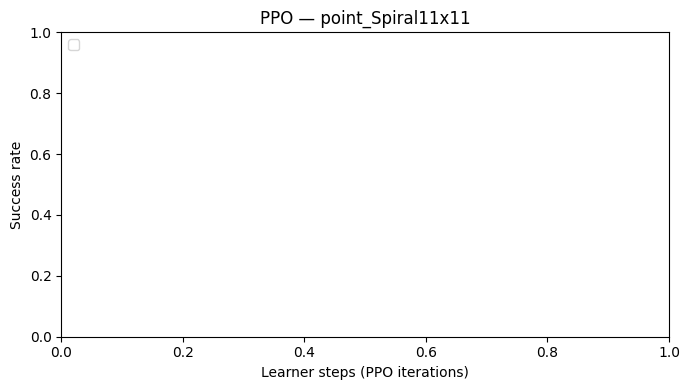

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_metric(
    LOG_DIR, ALG, ENV, SEEDS,
    metric='success_1000',
    x_col='learner_steps',
    csv_loader=load_eval_csv,
    label='PPO (φ·ψ reward)',
    color='steelblue',
)

ax.set_xlabel('Learner steps (PPO iterations)')
ax.set_ylabel('Success rate')
ax.set_title(f'PPO — {ENV}')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Per-seed success curves

  [warn] missing seed 0
  [warn] missing seed 1
  [warn] missing seed 2


/tmp/ipykernel_246073/1671723282.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


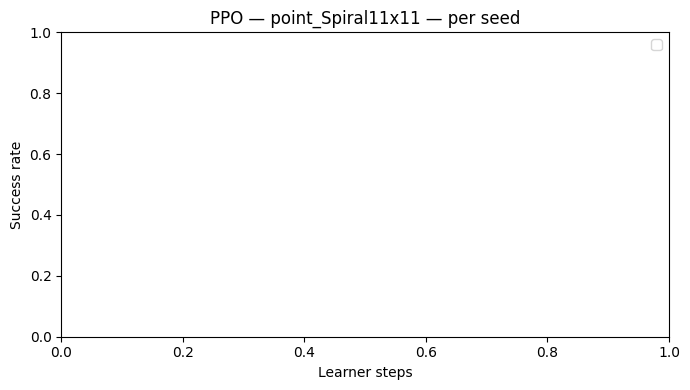

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_seeds_individually(
    LOG_DIR, ALG, ENV, SEEDS,
    metric='success_1000',
    x_col='learner_steps',
    csv_loader=load_eval_csv,
)

ax.set_xlabel('Learner steps')
ax.set_ylabel('Success rate')
ax.set_title(f'PPO — {ENV} — per seed')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Learner diagnostics

  [warn] missing seed 0
  [warn] missing seed 1
  [warn] missing seed 2
No data found for ppo/point_Spiral11x11/reward_repr_mean
  [warn] missing seed 0
  [warn] missing seed 1
  [warn] missing seed 2
No data found for ppo/point_Spiral11x11/crl/crl_loss
  [warn] missing seed 0
  [warn] missing seed 1
  [warn] missing seed 2
No data found for ppo/point_Spiral11x11/ep_return_mean


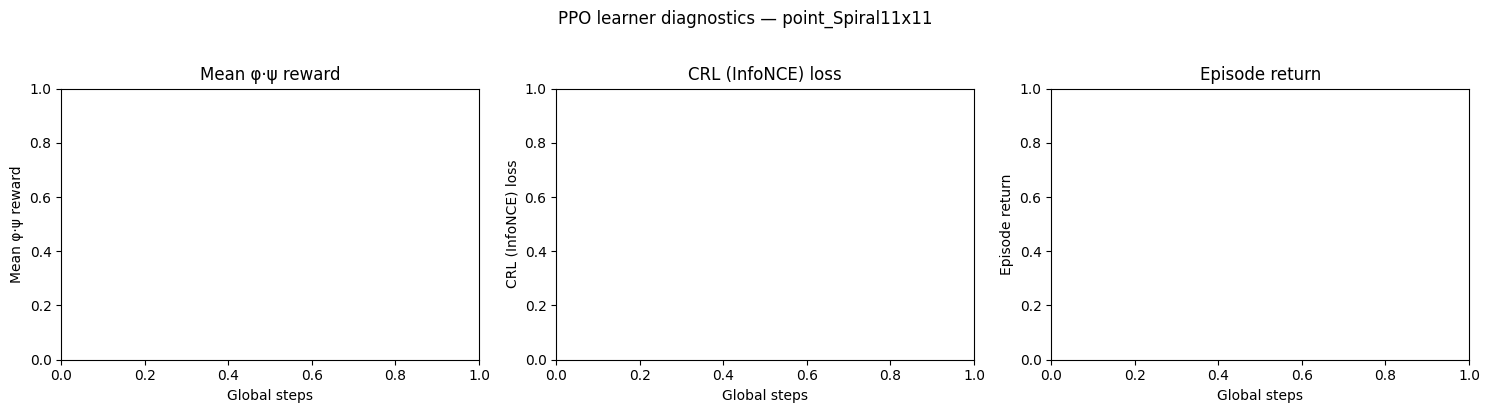

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

diagnostics = [
    ('reward_repr_mean', 'Mean φ·ψ reward',    'tomato'),
    ('crl/crl_loss',     'CRL (InfoNCE) loss', 'darkorange'),
    ('ep_return_mean',   'Episode return',      'steelblue'),
]

for ax, (metric, ylabel, color) in zip(axes, diagnostics):
    plt.sca(ax)
    plot_metric(
        LOG_DIR, ALG, ENV, SEEDS,
        metric=metric,
        x_col='global_step',
        csv_loader=load_learner_csv,
        label=ylabel,
        color=color,
        smoothing=5,
    )
    ax.set_xlabel('Global steps')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.suptitle(f'PPO learner diagnostics — {ENV}', y=1.02)
plt.tight_layout()
plt.show()

## Discount hyperparameter sweep

In [7]:
import numpy as np

TUNE_BASE_DIR = '/home/gliu2/dist_matching/sgcrl/logs/ppo_spiral11x11_discount_tune/'
DISCOUNT_VALUES = [round(i * 0.1, 2) for i in range(10)] + [0.99]
TUNE_SEEDS = [0, 1, 2]

def discount_tag(v):
    return f'{v:.2f}'.replace('.', 'p')

def discount_log_dir(v):
    return os.path.join(TUNE_BASE_DIR, f'discount_{discount_tag(v)}', '')

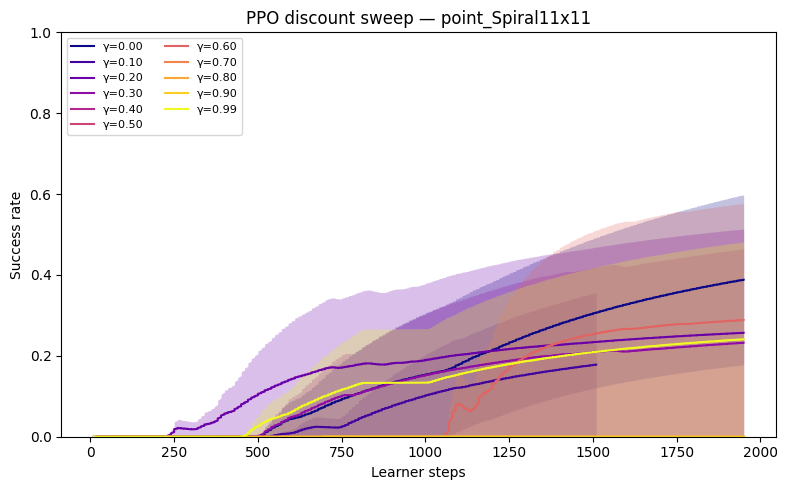

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.cm.plasma
colors = [cmap(i / (len(DISCOUNT_VALUES) - 1)) for i in range(len(DISCOUNT_VALUES))]

for v, color in zip(DISCOUNT_VALUES, colors):
    plot_metric(
        discount_log_dir(v), ALG, ENV, TUNE_SEEDS,
        metric='success_1000',
        x_col='learner_steps',
        csv_loader=load_eval_csv,
        label=f'γ={v:.2f}',
        color=color,
        smoothing=5,
    )

ax.set_xlabel('Learner steps')
ax.set_ylabel('Success rate')
ax.set_title(f'PPO discount sweep — {ENV}')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

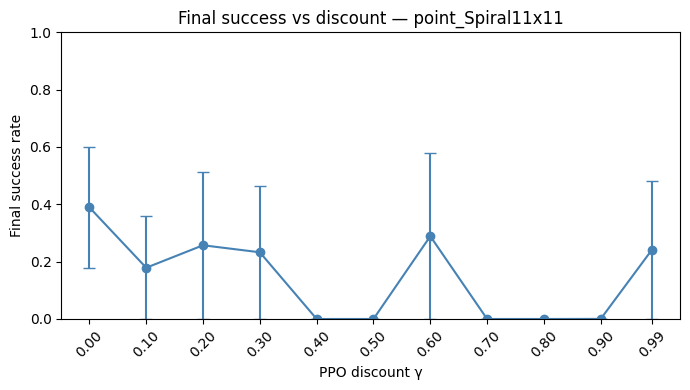

In [9]:
final_means, final_sems = [], []

for v in DISCOUNT_VALUES:
    arrays = []
    for seed in TUNE_SEEDS:
        try:
            df = load_eval_csv(discount_log_dir(v), ALG, ENV, seed)
            arrays.append(df['success_1000'].iloc[-1])
        except FileNotFoundError:
            pass
    if arrays:
        final_means.append(np.mean(arrays))
        final_sems.append(stats.sem(arrays))
    else:
        final_means.append(np.nan)
        final_sems.append(np.nan)

final_means = np.array(final_means)
final_sems  = np.array(final_sems)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(DISCOUNT_VALUES, final_means, yerr=final_sems, fmt='o-', color='steelblue', capsize=4)
ax.set_xlabel('PPO discount γ')
ax.set_ylabel('Final success rate')
ax.set_title(f'Final success vs discount — {ENV}')
ax.set_ylim(0, 1.0)
ax.set_xticks(DISCOUNT_VALUES)
ax.set_xticklabels([f'{v:.2f}' for v in DISCOUNT_VALUES], rotation=45)
plt.tight_layout()
plt.show()